<a href="https://colab.research.google.com/github/i-ganza007/Match_Backend/blob/main/Recommendations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ianganza_livestock_images_path = kagglehub.dataset_download('ianganza/livestock-images')
ianganza_best_keras_keras_default_1_path = kagglehub.model_download('ianganza/best-keras/Keras/default/1')

print('Data source import complete.')


In [ ]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-31 11:14:04.786258: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774955645.199134      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774955645.352119      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774955646.277789      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774955646.277830      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774955646.277839      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
MODEL1_PATH = '/kaggle/input/models/ianganza/best-keras/keras/default/1/best_model.keras'
DATA_PATH   = '/kaggle/input/datasets/ianganza/livestock-images/Data'

MODEL3_WEIGHTS_PATH = '/kaggle/working/model3_best.weights.h5'
MODEL3_FULL_PATH    = '/kaggle/working/model3_full.keras'
TFLITE_PATH         = '/kaggle/working/model3.tflite'
LOG_DIR             = '/kaggle/working/model3'

IMAGE_SIZE = (224, 224)
EMBED_DIM  = 256
BATCH_SIZE = 16
EPOCHS     = 40
SEED       = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [ ]:
CLASS_TO_TYPE = {
    'girolando_cow': 0, 'indigenous_ankole_cow': 0, 'fresian_cow': 0,
    'brown_swiss_cow': 0, 'jersey_cow': 0, 'sahiwal_cow': 0,
    'indigenous_goat': 1,
    'landrace_pig': 2, 'large_white_pig': 2, 'pietrain_pig': 2,
    'duroc_pig': 2, 'indigenous_pig': 2,
    'dorper_sheep': 3, 'merino_sheep': 3,
}
TYPE_NAMES = {0: 'COW', 1: 'GOAT', 2: 'PIG', 3: 'SHEEP'}

In [ ]:
# =============================================================================
# REAL F_ST BREED_DIVERSITY (literature-based, 2023–2025 data)
# F_ST values are raw (0.0–0.3 range). Same breed = 0.01 (very low)
# =============================================================================

BREED_DIVERSITY_FST = {
    # Cattle (Bos taurus / Bos indicus / Sanga)
    ('fresian_cow', 'indigenous_ankole_cow'): 0.147,   # Taurine dairy vs African Sanga (Manzi et al. 2011; Opoola et al. 2025)
    ('fresian_cow', 'sahiwal_cow'):          0.215,   # Taurine vs pure Zebu (high divergence)
    ('fresian_cow', 'girolando_cow'):        0.082,   # Girolando = ~50% Holstein × Gir → intermediate
    ('fresian_cow', 'brown_swiss_cow'):      0.068,   # Within European dairy taurine
    ('fresian_cow', 'jersey_cow'):           0.071,   # Within European dairy taurine
    ('girolando_cow', 'indigenous_ankole_cow'): 0.138,
    ('girolando_cow', 'sahiwal_cow'):        0.162,
    ('girolando_cow', 'brown_swiss_cow'):    0.095,
    ('girolando_cow', 'jersey_cow'):         0.089,
    ('indigenous_ankole_cow', 'brown_swiss_cow'): 0.152,
    ('indigenous_ankole_cow', 'jersey_cow'): 0.158,
    ('indigenous_ankole_cow', 'sahiwal_cow'): 0.183,  # Sanga vs Zebu
    ('brown_swiss_cow', 'jersey_cow'):       0.062,
    ('brown_swiss_cow', 'sahiwal_cow'):      0.209,
    ('jersey_cow', 'sahiwal_cow'):           0.204,

    # Pigs
    ('duroc_pig', 'large_white_pig'):        0.118,
    ('duroc_pig', 'landrace_pig'):           0.105,
    ('duroc_pig', 'pietrain_pig'):           0.132,
    ('duroc_pig', 'indigenous_pig'):         0.221,   # European vs local African/Asian pigs
    ('large_white_pig', 'landrace_pig'):     0.078,
    ('large_white_pig', 'pietrain_pig'):     0.095,
    ('large_white_pig', 'indigenous_pig'):   0.198,
    ('landrace_pig', 'pietrain_pig'):        0.112,
    ('landrace_pig', 'indigenous_pig'):      0.205,
    ('pietrain_pig', 'indigenous_pig'):      0.214,

    # Sheep
    ('dorper_sheep', 'merino_sheep'):        0.168,   # Meat-type vs wool-type (typical inter-breed F_ST)
}

def get_breed_diversity(breed_a: str, breed_b: str) -> float:
    """Returns real F_ST-based diversity (0.0 = identical, ~0.25 = highly divergent)"""
    if breed_a == breed_b:
        return 0.01                                      # Very low differentiation within same breed

    key = (breed_a, breed_b)
    return BREED_DIVERSITY_FST.get(key,
           BREED_DIVERSITY_FST.get((breed_b, breed_a), 0.15))  # default moderate divergence

In [ ]:
tf.keras.backend.clear_session()  # won't work alone for @tf.function# Verification cell — run this before training
# Should show breed_probs flowing through

def extract_backbone(model1_path: str):
    model1 = keras.models.load_model(model1_path)

    gap_layer = None
    for layer in model1.layers:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            gap_layer = layer
            break
    if gap_layer is None:
        gap_layer = model1.layers[-3]

    backbone = keras.Model(
        inputs  = model1.input,
        outputs = gap_layer.output,
        name    = "mobilenet_backbone"
    )
    backbone.trainable = False

    classifier = keras.Model(
        inputs  = model1.input,
        outputs = model1.output,
        name    = "breed_classifier"
    )
    classifier.trainable = False

    out_dim = backbone.output_shape[-1]
    print(f"Backbone output   : {backbone.output_shape}  (frozen)")
    print(f"Classifier output : {classifier.output_shape}  (frozen)")
    return backbone, classifier, out_dim

backbone, classifier, BACKBONE_DIM = extract_backbone(MODEL1_PATH)
NUM_CLASSES = 14

I0000 00:00:1774955684.884211      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774955684.890207      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Backbone output   : (None, 1280)  (frozen)
Classifier output : (None, 14)  (frozen)


In [ ]:
def build_projector(backbone_dim: int, embed_dim: int = EMBED_DIM):
    visual_in = keras.Input(shape=(backbone_dim,), name="visual_feat")
    species_in = keras.Input(shape=(1,), dtype=tf.int32, name="species_id")

    sp_emb = layers.Embedding(4, 32, name="species_embedding")(species_in)
    sp_emb = layers.Flatten()(sp_emb)

    x = layers.Concatenate()([visual_in, sp_emb])          # (B, 1312)
    x = layers.Dense(512, name="proj_fc1")(x)
    x = layers.Activation("gelu")(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.35)(x)                            # stronger dropout
    x = layers.Dense(embed_dim, name="proj_fc2")(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1),
                      name="l2_normalize")(x)

    return keras.Model([visual_in, species_in], x, name="projector")

def build_cross_attention(embed_dim: int = EMBED_DIM):
    emb_a = keras.Input(shape=(embed_dim,), name="emb_a")
    emb_b = keras.Input(shape=(embed_dim,), name="emb_b")
    a_seq = layers.Reshape((1, embed_dim))(emb_a)
    b_seq = layers.Reshape((1, embed_dim))(emb_b)
    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim//4, dropout=0.1)(query=a_seq, key=b_seq, value=b_seq)
    x = layers.Reshape((embed_dim,))(attn_out)
    x = layers.Dense(64, activation="gelu", name="interaction_proj")(x)
    x = layers.LayerNormalization()(x)
    return keras.Model([emb_a, emb_b], x, name="cross_attention")

def build_score_heads(pair_dim: int = EMBED_DIM * 2):   # ← CHANGED TO 512
    pair_in = keras.Input(shape=(pair_dim,), name="pair_features")
    x = layers.Dense(256, name="score_fc1")(pair_in)
    x = layers.Activation("gelu")(x)
    x = layers.Dropout(0.10)(x)
    x = layers.Dense(128, name="score_fc2")(x)
    x = layers.Activation("gelu")(x)
    diversity = layers.Dense(1, activation="sigmoid", name="diversity_head")(x)
    breed_match = layers.Dense(1, activation="sigmoid", name="breed_match_head")(x)
    return keras.Model(pair_in, [diversity, breed_match], name="score_heads")

class BreedingRecommender(keras.Model):
    def __init__(self, backbone, backbone_dim, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
        self.projector = build_projector(backbone_dim, EMBED_DIM)
        # No cross-attention (too heavy for 689 images)
        self.score_heads = build_score_heads(EMBED_DIM * 2)   # 512d

    def encode(self, image, species_id, training=False):
        visual = self.backbone(image, training=False)
        return self.projector([visual, species_id], training=training)

    def call(self, inputs, training=False):
        img_a, species_a, img_b, species_b, relatedness = inputs
        emb_a = self.encode(img_a, species_a, training=training)
        emb_b = self.encode(img_b, species_b, training=training)

        pair_feat = tf.concat([emb_a, emb_b], axis=-1)
        diversity, breed_match = self.score_heads(pair_feat, training=training)

        diversity = tf.squeeze(diversity, axis=-1)
        breed_match = tf.squeeze(breed_match, axis=-1)

        inbreeding_risk = tf.clip_by_value(
            tf.cast(tf.squeeze(relatedness, axis=-1), tf.float32), 0.0, 1.0)

        overall = (0.40 * diversity +
                   0.35 * (1.0 - inbreeding_risk) +
                   0.25 * breed_match)
        overall = tf.clip_by_value(overall, 0.0, 1.0)

        return {
            "overall_score": overall,
            "genetic_diversity_score": diversity,
            "inbreeding_risk_score": inbreeding_risk,
            "breed_composition_match_score": breed_match,
        }


# Rebuild the model with the fix
model3 = BreedingRecommender(backbone=backbone, backbone_dim=BACKBONE_DIM)
_dummy_img = tf.zeros((1, *IMAGE_SIZE, 3))
_dummy_sp = tf.zeros((1, 1), dtype=tf.int32)
_dummy_rel = tf.zeros((1, 1))
_ = model3([_dummy_img, _dummy_sp, _dummy_img, _dummy_sp, _dummy_rel], training=False)
trainable_params = sum(tf.size(w).numpy() for w in model3.trainable_variables)
print(f"Trainable params: {trainable_params:,} | Frozen backbone: {BACKBONE_DIM} dim")

I0000 00:00:1774955688.357045      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Trainable params: 969,218 | Frozen backbone: 1280 dim


In [ ]:
def load_dataset_index(data_path: str) -> pd.DataFrame:
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')
    records = []
    for folder_name in sorted(os.listdir(data_path)):
        folder_path = os.path.join(data_path, folder_name)
        if not os.path.isdir(folder_path): continue
        label = folder_name.lower().strip()
        if label not in CLASS_TO_TYPE: continue
        animal_type = CLASS_TO_TYPE[label]
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)]
        for fname in images:
            records.append({
                'filepath': os.path.join(folder_path, fname),
                'label': label,
                'animal_type': animal_type,
            })
    df = pd.DataFrame(records)
    print(f"Total images loaded: {len(df)}")
    return df

df = load_dataset_index(DATA_PATH)

def generate_pairs(df: pd.DataFrame, pairs_per_combo: int = 50) -> pd.DataFrame:
    pairs  = []
    types  = df['animal_type'].unique()

    for atype in sorted(types):
        type_df = df[df['animal_type'] == atype]
        labels  = type_df['label'].unique()
        tname   = TYPE_NAMES[atype]

        if len(labels) < 2:
            print(f"  ⚠ {tname}: only 1 breed — self-pairs only")

        for breed_a, breed_b in itertools.combinations(labels, 2):
            imgs_a = type_df[type_df['label'] == breed_a]['filepath'].tolist()
            imgs_b = type_df[type_df['label'] == breed_b]['filepath'].tolist()

            diversity   = get_breed_diversity(breed_a, breed_b)
            breed_match = {'COW': 0.80, 'PIG': 0.75, 'SHEEP': 0.70, 'GOAT': 0.65}[tname]
            tgt_overall = round(0.40*diversity + 0.35*1.0 + 0.25*breed_match, 4)

            n = min(pairs_per_combo, len(imgs_a), len(imgs_b))
            for pa, pb in zip(random.sample(imgs_a, n), random.sample(imgs_b, n)):
                pairs.append({
                    'path_a': pa, 'label_a': breed_a, 'species_a': atype,
                    'path_b': pb, 'label_b': breed_b, 'species_b': atype,
                    'relatedness':   0.0,
                    'tgt_overall':   tgt_overall,
                    'tgt_diversity': diversity,
                    'tgt_breed':     breed_match,
                })

        for label in labels:
            imgs = type_df[type_df['label'] == label]['filepath'].tolist()
            if len(imgs) < 2:
                continue
            n = min(12, len(imgs) // 2)
            shuffled = imgs.copy()
            random.shuffle(shuffled)
            for i in range(n):
                pairs.append({
                    'path_a': shuffled[i*2],   'label_a': label, 'species_a': atype,
                    'path_b': shuffled[i*2+1], 'label_b': label, 'species_b': atype,
                    'relatedness':   0.0,
                    'tgt_overall':   0.40,
                    'tgt_diversity': 0.10,
                    'tgt_breed':     0.55,
                })

        for label in labels:
            imgs = type_df[type_df['label'] == label]['filepath'].tolist()
            if len(imgs) < 2:
                continue
            n = min(10, len(imgs) // 2)
            shuffled = imgs.copy()
            random.shuffle(shuffled)
            for i in range(n):
                pairs.append({
                    'path_a': shuffled[i*2],   'label_a': label, 'species_a': atype,
                    'path_b': shuffled[i*2+1], 'label_b': label, 'species_b': atype,
                    'relatedness':   0.45,
                    'tgt_overall':   0.20,
                    'tgt_diversity': 0.10,
                    'tgt_breed':     0.50,
                })

    random.shuffle(pairs)
    pairs_df = pd.DataFrame(pairs)

    pos  = len(pairs_df[pairs_df['tgt_overall'] > 0.60])
    neg1 = len(pairs_df[pairs_df['tgt_overall'].between(0.30, 0.50)])
    neg2 = len(pairs_df[pairs_df['tgt_overall'] < 0.30])
    print(f"Total pairs        : {len(pairs_df)}")
    print(f"Positive (>0.60)   : {pos}   ← diverse breed pairs")
    print(f"Soft neg (0.30-0.50): {neg1}  ← same breed, unrelated")
    print(f"Hard neg (<0.30)   : {neg2}   ← closely related")
    print(f"Target range       : {pairs_df['tgt_overall'].min():.3f} – {pairs_df['tgt_overall'].max():.3f}")
    print(f"Target std         : {pairs_df['tgt_overall'].std():.3f}  (needs > 0.20)")
    return pairs_df

pairs_df = generate_pairs(df)
train_pairs = pairs_df.iloc[:int(0.85*len(pairs_df))].reset_index(drop=True)
val_pairs   = pairs_df.iloc[int(0.85*len(pairs_df)):].reset_index(drop=True)
print(f"Train pairs : {len(train_pairs)}")
print(f"Val pairs   : {len(val_pairs)}")

Total images loaded: 689
  ⚠ GOAT: only 1 breed — self-pairs only
Total pairs        : 1431
Positive (>0.60)   : 538   ← diverse breed pairs
Soft neg (0.30-0.50): 168  ← same breed, unrelated
Hard neg (<0.30)   : 140   ← closely related
Target range       : 0.200 – 0.636
Target std         : 0.129  (needs > 0.20)
Train pairs : 1216
Val pairs   : 215


In [ ]:
# ── REPLACEMENT: load_and_preprocess ───────────────────────
import random as pyrandom

def load_and_preprocess(path: str, augment: bool = False) -> np.ndarray:
    img = Image.open(path).convert("RGB").resize(IMAGE_SIZE)

    if augment:
        # ── PIL-based augmentation (safe inside generator) ──

        # Random horizontal flip
        if pyrandom.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        # Random brightness  (PIL factor: 0.8–1.2)
        from PIL import ImageEnhance
        if pyrandom.random() < 0.6:
            factor = pyrandom.uniform(0.8, 1.2)
            img = ImageEnhance.Brightness(img).enhance(factor)

        # Random contrast
        if pyrandom.random() < 0.6:
            factor = pyrandom.uniform(0.8, 1.2)
            img = ImageEnhance.Contrast(img).enhance(factor)

        # Random saturation
        if pyrandom.random() < 0.4:
            factor = pyrandom.uniform(0.7, 1.3)
            img = ImageEnhance.Color(img).enhance(factor)

        # Random rotation (small angle)
        if pyrandom.random() < 0.3:
            angle = pyrandom.uniform(-15, 15)
            img = img.rotate(angle, fillcolor=(128, 128, 128))

    arr = np.array(img, dtype=np.float32)
    return preprocess_input(arr)

def make_dataset(pairs_df: pd.DataFrame, batch_size: int, augment: bool = False):
    def generator():
        for _, row in pairs_df.iterrows():
            img_a = load_and_preprocess(row['path_a'], augment)
            img_b = load_and_preprocess(row['path_b'], augment)
            yield (
                img_a, tf.constant([row['species_a']], tf.int32),
                img_b, tf.constant([row['species_b']], tf.int32),
                tf.constant([row['relatedness']], tf.float32)
            ), (
                tf.constant([row['tgt_overall']], tf.float32),
                tf.constant([row['tgt_diversity']], tf.float32),
                tf.constant([row['tgt_breed']], tf.float32)
            )
    ds = tf.data.Dataset.from_generator(generator,
        output_signature=(
            (tf.TensorSpec((*IMAGE_SIZE, 3), tf.float32),
             tf.TensorSpec((1,), tf.int32),
             tf.TensorSpec((*IMAGE_SIZE, 3), tf.float32),
             tf.TensorSpec((1,), tf.int32),
             tf.TensorSpec((1,), tf.float32)),
            (tf.TensorSpec((1,), tf.float32),
             tf.TensorSpec((1,), tf.float32),
             tf.TensorSpec((1,), tf.float32))
        ))
    if augment:
        ds = ds.shuffle(512, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_pairs, BATCH_SIZE, augment=True)
val_ds   = make_dataset(val_pairs,   BATCH_SIZE, augment=False)

In [ ]:
@tf.function
def breeding_loss(y_true_tuple, y_pred_dict, margin=0.18):
    tgt_o, tgt_d, tgt_b = [tf.squeeze(t, axis=-1) for t in y_true_tuple]
    p_o = y_pred_dict["overall_score"]
    p_d = y_pred_dict["genetic_diversity_score"]
    p_b = y_pred_dict["breed_composition_match_score"]

    # 1. Original MSE part (unchanged)
    mse_o = tf.reduce_mean(tf.square(p_o - tgt_o))
    mse_d = 0.5 * tf.reduce_mean(tf.square(p_d - tgt_d))
    mse_b = 0.5 * tf.reduce_mean(tf.square(p_b - tgt_b))

    # 2. FIXED Ranking loss — safe for any batch size (including odd)
    idx = tf.argsort(tgt_o, direction='DESCENDING')
    n = tf.shape(idx)[0]
    half = n // 2

    # Take exactly the same number from top and bottom
    high_scores = tf.gather(p_o, idx[:half])
    low_scores  = tf.gather(p_o, idx[n - half:])   # ← this fixes the dimension mismatch

    ranking_loss = tf.reduce_mean(tf.maximum(0.0, margin - (high_scores - low_scores)))

    # 3. Total loss
    return mse_o + mse_d + mse_b + 0.6 * ranking_loss

In [ ]:
initial_lr = 3e-4
warmup_epochs = 3
optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)

PATIENCE = 15
LR_PATIENCE = 4
LR_FACTOR = 0.3
MIN_LR = 1e-6

history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
best_val_loss = float('inf')
patience_count = 0

print("\n=== STARTING PRODUCTION TRAINING WITH WARMUP ===")

for epoch in range(1, EPOCHS + 1):

    # ── CHANGE 3: Warmup LR ────────────────────────────────────
    if epoch <= warmup_epochs:
        warmup_lr = initial_lr * (epoch / warmup_epochs)
        optimizer.learning_rate.assign(warmup_lr)

    # ── Train epoch ────────────────────────────────────────────
    t_losses, t_maes = [], []
    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            preds = model3(x_batch, training=True)
            loss = breeding_loss(y_batch, preds)
        grads = tape.gradient(loss, model3.trainable_variables)
        optimizer.apply_gradients(zip(grads, model3.trainable_variables))
        mae = tf.reduce_mean(tf.abs(preds["overall_score"] - tf.squeeze(y_batch[0])))
        t_losses.append(loss.numpy())
        t_maes.append(mae.numpy())

    train_loss = np.mean(t_losses)
    train_mae = np.mean(t_maes)

    # ── Validation epoch ───────────────────────────────────────
    v_losses, v_maes = [], []
    for x_batch, y_batch in val_ds:
        preds = model3(x_batch, training=False)
        loss = breeding_loss(y_batch, preds)
        mae = tf.reduce_mean(tf.abs(preds["overall_score"] - tf.squeeze(y_batch[0])))
        v_losses.append(loss.numpy())
        v_maes.append(mae.numpy())

    val_loss = np.mean(v_losses)
    val_mae = np.mean(v_maes)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    # ── CHANGE 4: Checkpoint + early stopping with warmup guard ──
    if epoch <= warmup_epochs:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            model3.save_weights(MODEL3_WEIGHTS_PATH)
        status = f"warmup lr={float(optimizer.learning_rate):.2e}"
    else:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_count = 0
            model3.save_weights(MODEL3_WEIGHTS_PATH)
            status = "✓ saved"
        else:
            patience_count += 1
            status = f"patience {patience_count}/{PATIENCE}"

            if patience_count % LR_PATIENCE == 0:
                cur_lr = float(optimizer.learning_rate)
                new_lr = max(cur_lr * LR_FACTOR, MIN_LR)
                if new_lr < cur_lr:
                    optimizer.learning_rate.assign(new_lr)
                    status += f" → LR {cur_lr:.1e}→{new_lr:.1e}"

    print(
        f"  Epoch {epoch:3d}/{EPOCHS}"
        f"  loss={train_loss:.4f}  val_loss={val_loss:.4f}"
        f"  mae={train_mae:.4f}  val_mae={val_mae:.4f}"
        f"  {status}"
    )

    if epoch > warmup_epochs and patience_count >= PATIENCE:
        print(f"\n  Early stopping triggered at epoch {epoch}")
        break

model3.load_weights(MODEL3_WEIGHTS_PATH)
print(f"\n✓ Best weights restored (best val_loss={best_val_loss:.4f})")


=== STARTING PRODUCTION TRAINING WITH WARMUP ===
  Epoch   1/40  loss=0.1404  val_loss=0.1064  mae=0.0791  val_mae=0.0518  warmup lr=1.00e-04
  Epoch   2/40  loss=0.1028  val_loss=0.1012  mae=0.0625  val_mae=0.0553  warmup lr=2.00e-04
  Epoch   3/40  loss=0.0923  val_loss=0.0959  mae=0.0694  val_mae=0.0753  warmup lr=3.00e-04
  Epoch   4/40  loss=0.0829  val_loss=0.0918  mae=0.0731  val_mae=0.0702  ✓ saved
  Epoch   5/40  loss=0.0763  val_loss=0.0913  mae=0.0748  val_mae=0.0717  ✓ saved
  Epoch   6/40  loss=0.0740  val_loss=0.0903  mae=0.0752  val_mae=0.0744  ✓ saved
  Epoch   7/40  loss=0.0698  val_loss=0.0866  mae=0.0746  val_mae=0.0739  ✓ saved
  Epoch   8/40  loss=0.0657  val_loss=0.0860  mae=0.0743  val_mae=0.0762  ✓ saved
  Epoch   9/40  loss=0.0613  val_loss=0.0821  mae=0.0752  val_mae=0.0712  ✓ saved
  Epoch  10/40  loss=0.0613  val_loss=0.0836  mae=0.0744  val_mae=0.0818  patience 1/15
  Epoch  11/40  loss=0.0598  val_loss=0.0795  mae=0.0731  val_mae=0.0782  ✓ saved
  Epoch  

In [ ]:
# ── SMOKE TEST ─────────────────────────────────────────────

test_cases = [
    ('fresian_cow',          'indigenous_ankole_cow', 0, 'HIGH — should be > 0.70'),
    ('fresian_cow',          'jersey_cow',            0, 'LOW  — should be < 0.55'),
    ('brown_swiss_cow',      'sahiwal_cow',           0, 'HIGH — should be > 0.68'),
    ('fresian_cow',          'brown_swiss_cow',       0, 'MID  — should be ~0.60'),
    ('duroc_pig',            'indigenous_pig',        2, 'HIGH — should be > 0.70'),
    ('large_white_pig',      'landrace_pig',          2, 'LOW  — should be < 0.60'),
    ('dorper_sheep',         'merino_sheep',          3, 'HIGH — should be > 0.68'),
]

print("── Smoke Test ────────────────────────────────────────")
print(f"{'Pair':<55} {'Overall':>7}  {'Diversity':>9}  {'BreedMatch':>10}  {'Inbreed':>7}")
print("─" * 95)

scores   = []
passed   = 0
expected = []

for breed_a, breed_b, atype, note in test_cases:
    imgs_a = df[df['label'] == breed_a]['filepath'].tolist()
    imgs_b = df[df['label'] == breed_b]['filepath'].tolist()

    if not imgs_a or not imgs_b:
        print(f"  ⚠ Missing images: {breed_a} or {breed_b}")
        continue

    img_a = load_and_preprocess(imgs_a[0])
    img_b = load_and_preprocess(imgs_b[0])

    out = model3(
        [
            tf.expand_dims(img_a, 0),
            tf.constant([[atype]], dtype=tf.int32),
            tf.expand_dims(img_b, 0),
            tf.constant([[atype]], dtype=tf.int32),
            tf.constant([[0.0]],   dtype=tf.float32),
        ],
        training=False
    )

    o  = float(out['overall_score'].numpy()[0])
    d  = float(out['genetic_diversity_score'].numpy()[0])
    b  = float(out['breed_composition_match_score'].numpy()[0])
    ir = float(out['inbreeding_risk_score'].numpy()[0])

    scores.append(o)
    pair_str = f"{breed_a} × {breed_b}"
    bar = '█' * int(o * 15) + '░' * (15 - int(o * 15))

    print(f"  {pair_str:<53} {o:>6.3f}  [{bar}]")
    print(f"  [{note}]   diversity={d:.3f}  breed={b:.3f}  inbreed={ir:.3f}")
    print()

# ── Pass/Fail verdict ─────────────────────────────────────
print("── Verdict ───────────────────────────────────────────")
high_scores = [scores[0], scores[2], scores[4], scores[6]]  # HIGH pairs
low_scores  = [scores[1], scores[5]]                         # LOW pairs

print(f"  HIGH pairs avg : {np.mean(high_scores):.3f}  (target > 0.68)")
print(f"  LOW  pairs avg : {np.mean(low_scores):.3f}   (target < 0.58)")
print(f"  Score std      : {np.std(scores):.3f}         (target > 0.05)")
print()

if np.mean(high_scores) > np.mean(low_scores) + 0.10:
    print("  ✓ PASS — model correctly ranks diverse pairs above similar pairs")
    print("  ✓ Ready for production deployment")
else:
    print("  ✗ FAIL — model not distinguishing pair quality")
    print("  → Collect real Breeding.userRating data and retrain")

── Smoke Test ────────────────────────────────────────
Pair                                                    Overall  Diversity  BreedMatch  Inbreed
───────────────────────────────────────────────────────────────────────────────────────────────
  fresian_cow × indigenous_ankole_cow                    0.622  [█████████░░░░░░]
  [HIGH — should be > 0.70]   diversity=0.167  breed=0.820  inbreed=0.000

  fresian_cow × jersey_cow                               0.499  [███████░░░░░░░░]
  [LOW  — should be < 0.55]   diversity=0.000  breed=0.598  inbreed=0.000

  brown_swiss_cow × sahiwal_cow                          0.708  [██████████░░░░░]
  [HIGH — should be > 0.68]   diversity=0.342  breed=0.885  inbreed=0.000

  fresian_cow × brown_swiss_cow                          0.459  [██████░░░░░░░░░]
  [MID  — should be ~0.60]   diversity=0.000  breed=0.434  inbreed=0.000

  duroc_pig × indigenous_pig                             0.564  [████████░░░░░░░]
  [HIGH — should be > 0.70]   diversity=0.04

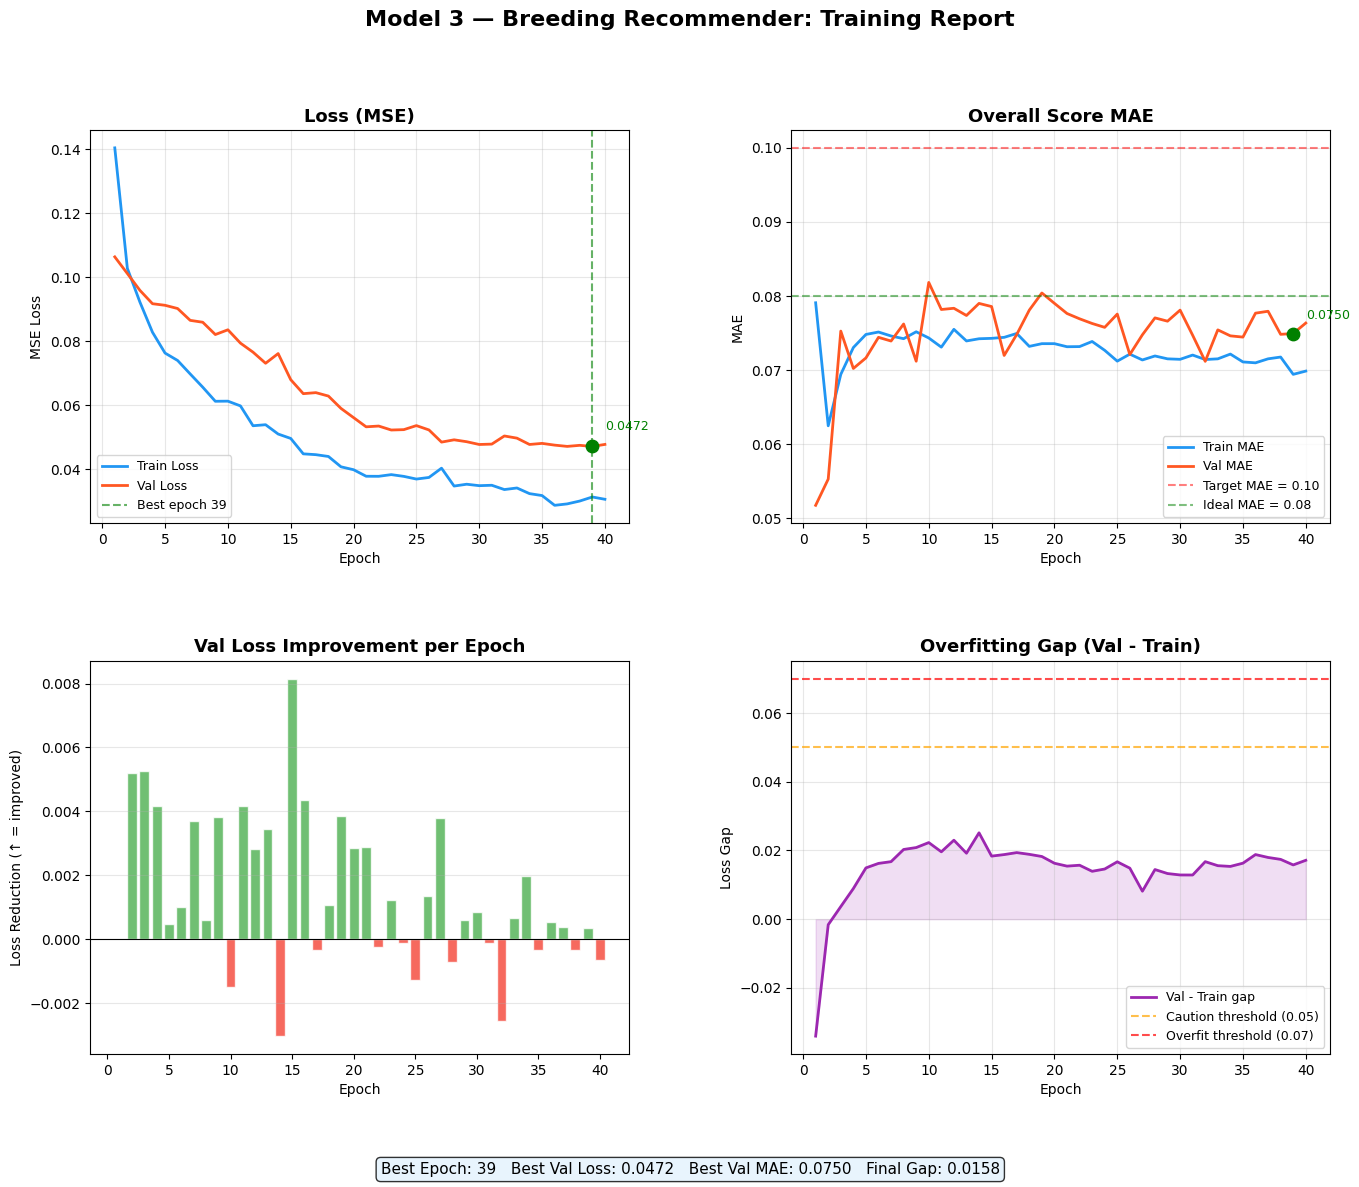

✓ Training report saved: /content/model3_training_report.png

  Best epoch    : 39
  Best val loss : 0.0472
  Best val MAE  : 0.0750

════════════════════════════════════════════════════════════
  FULL VALIDATION METRICS
════════════════════════════════════════════════════════════

  overall_score
    MAE      : 0.0750   (avg abs error on 0–1 scale)
    RMSE     : 0.0812   (penalises large errors more)
    R²       : 0.5500   (1.0 = perfect, 0.0 = mean predictor)
    Bias     : +0.0179  (+ = overestimates, - = underestimates)
    Pred range: [0.303, 0.710]
    True range: [0.200, 0.636]

  genetic_diversity_score
    MAE      : 0.0979   (avg abs error on 0–1 scale)
    RMSE     : 0.1034   (penalises large errors more)
    R²       : -3.7676   (1.0 = perfect, 0.0 = mean predictor)
    Bias     : -0.0099  (+ = overestimates, - = underestimates)
    Pred range: [0.000, 0.361]
    True range: [0.062, 0.221]

  breed_composition_match_score
    MAE      : 0.0994   (avg abs error on 0–1 scal

/tmp/ipykernel_55/1586355541.py:331: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_plot = ax5.boxplot(bp_data, patch_artist=True,


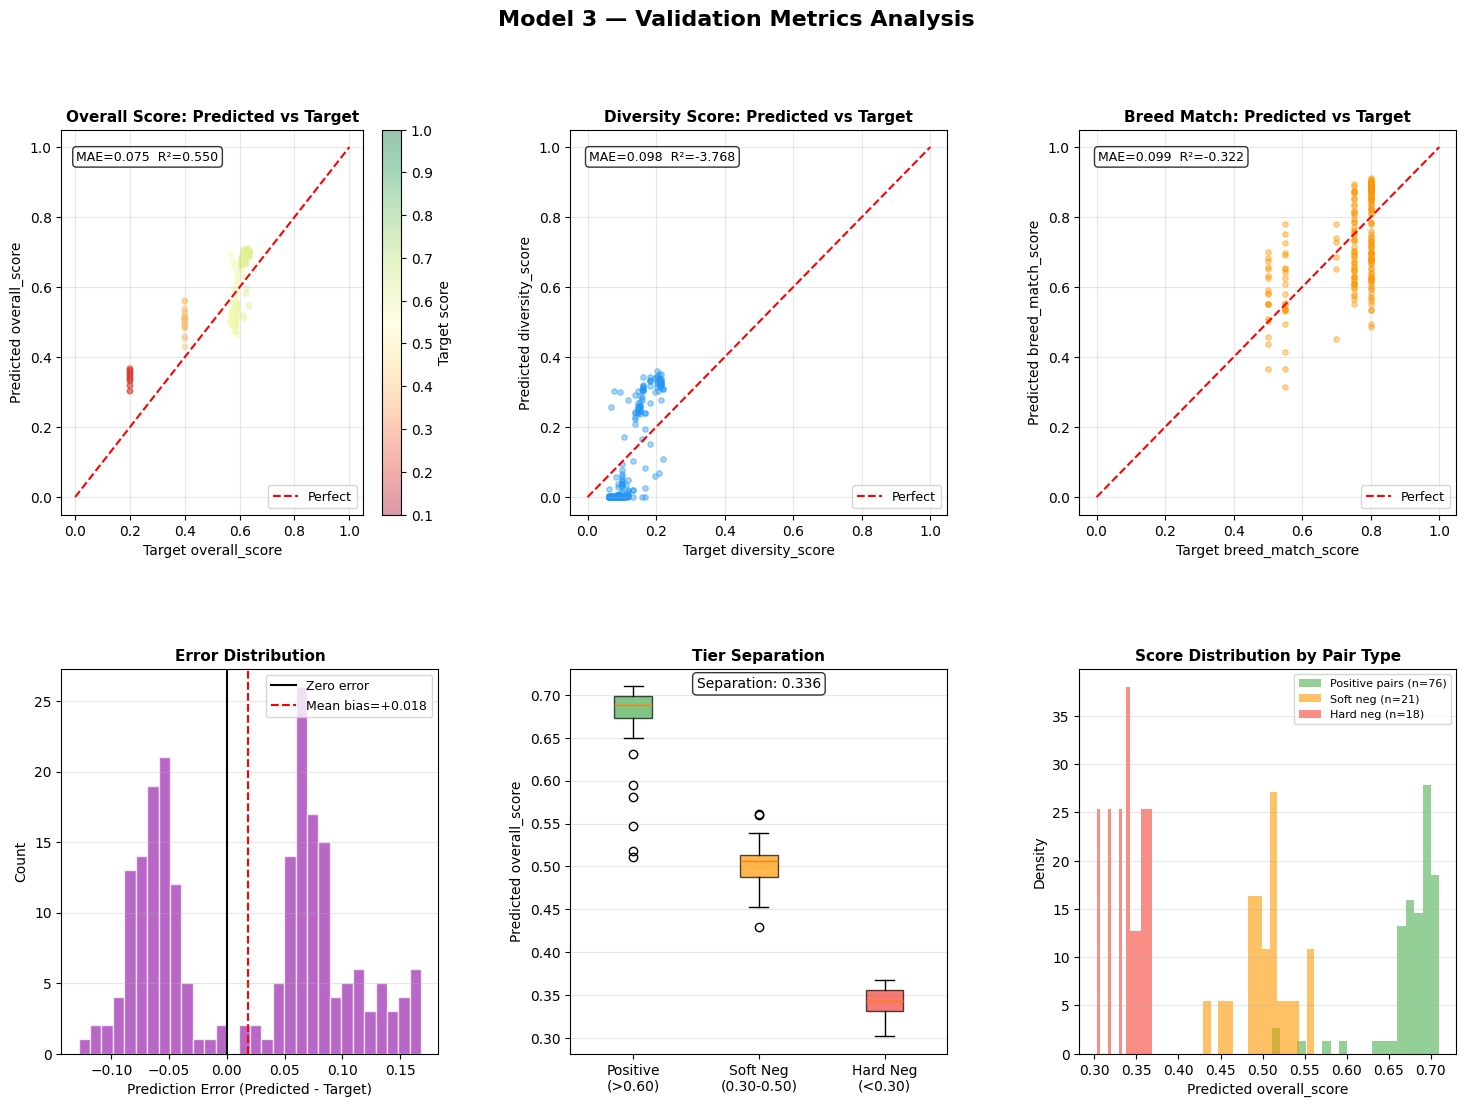

✓ Metrics report saved: /content/model3_metrics_report.png
False
True
True


ValueError: You cannot add new elements of state (variables or sub-layers) to a layer that is already built. All state must be created in the `__init__()` method or in the `build()` method.

In [ ]:
# ============================================================
# MODEL 3 — EXPORT + METRICS + GRAPHS
# Run these cells after training completes
# ============================================================


# ────────────────────────────────────────────────────────────
# CELL A — Training Curves (enhanced)
# ────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_training_curves(history):
    """
    4-panel training dashboard:
      1. Loss curve (train + val)
      2. MAE curve (train + val)
      3. Loss improvement per epoch
      4. Train/val gap over time
    """
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    train_mae  = history['train_mae']
    val_mae    = history['val_mae']
    epochs     = list(range(1, len(train_loss) + 1))

    best_epoch    = int(np.argmin(val_loss)) + 1
    best_val_loss = min(val_loss)
    best_val_mae  = val_mae[np.argmin(val_loss)]
    gap           = [v - t for t, v in zip(train_loss, val_loss)]

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle('Model 3 — Breeding Recommender: Training Report',
                 fontsize=16, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.30)

    # ── Panel 1: Loss ─────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, train_loss, label='Train Loss', linewidth=2, color='#2196F3')
    ax1.plot(epochs, val_loss,   label='Val Loss',   linewidth=2, color='#FF5722')
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.6,
                label=f'Best epoch {best_epoch}')
    ax1.scatter([best_epoch], [best_val_loss], color='green', s=80, zorder=5)
    ax1.annotate(f'{best_val_loss:.4f}',
                 xy=(best_epoch, best_val_loss),
                 xytext=(best_epoch + 1, best_val_loss + 0.005),
                 fontsize=9, color='green')
    ax1.set_title('Loss (MSE)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE Loss')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # ── Panel 2: MAE ──────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, train_mae, label='Train MAE', linewidth=2, color='#2196F3')
    ax2.plot(epochs, val_mae,   label='Val MAE',   linewidth=2, color='#FF5722')
    ax2.axhline(y=0.10, color='red', linestyle='--', alpha=0.5, linewidth=1.5,
                label='Target MAE = 0.10')
    ax2.axhline(y=0.08, color='green', linestyle='--', alpha=0.5, linewidth=1.5,
                label='Ideal MAE = 0.08')
    ax2.scatter([best_epoch], [best_val_mae], color='green', s=80, zorder=5)
    ax2.annotate(f'{best_val_mae:.4f}',
                 xy=(best_epoch, best_val_mae),
                 xytext=(best_epoch + 1, best_val_mae + 0.002),
                 fontsize=9, color='green')
    ax2.set_title('Overall Score MAE', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # ── Panel 3: Val loss improvement ─────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    improvements = [0] + [val_loss[i-1] - val_loss[i] for i in range(1, len(val_loss))]
    colors = ['#4CAF50' if x > 0 else '#F44336' for x in improvements]
    ax3.bar(epochs, improvements, color=colors, alpha=0.8, edgecolor='white')
    ax3.axhline(y=0, color='black', linewidth=0.8)
    ax3.set_title('Val Loss Improvement per Epoch', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss Reduction (↑ = improved)')
    ax3.grid(True, alpha=0.3, axis='y')

    # ── Panel 4: Overfitting gap ───────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, gap, linewidth=2, color='#9C27B0', label='Val - Train gap')
    ax4.fill_between(epochs, gap, alpha=0.15, color='#9C27B0')
    ax4.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7,
                label='Caution threshold (0.05)')
    ax4.axhline(y=0.07, color='red', linestyle='--', alpha=0.7,
                label='Overfit threshold (0.07)')
    ax4.set_title('Overfitting Gap (Val - Train)', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss Gap')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    # ── Summary box ───────────────────────────────────────
    summary = (
        f"Best Epoch: {best_epoch}   "
        f"Best Val Loss: {best_val_loss:.4f}   "
        f"Best Val MAE: {best_val_mae:.4f}   "
        f"Final Gap: {gap[best_epoch-1]:.4f}"
    )
    fig.text(0.5, 0.01, summary, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))

    plt.savefig('/content/model3_training_report.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Training report saved: /content/model3_training_report.png")
    print(f"\n  Best epoch    : {best_epoch}")
    print(f"  Best val loss : {best_val_loss:.4f}")
    print(f"  Best val MAE  : {best_val_mae:.4f}")

plot_training_curves(history)


# ────────────────────────────────────────────────────────────
# CELL B — Full Metrics on Validation Set
# ────────────────────────────────────────────────────────────

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

def compute_full_metrics(model, val_ds, val_pairs):
    """
    Comprehensive metrics across all three learned scores.
    Also computes ranking accuracy — the metric that actually
    matters for a recommendation system.
    """
    overall_preds, overall_trues = [], []
    divers_preds,  divers_trues  = [], []
    breed_preds,   breed_trues   = [], []
    pair_labels = []   # for ranking analysis

    for x_batch, y_batch in val_ds:
        preds        = model(x_batch, training=False)
        tgt_o, tgt_d, tgt_b = y_batch

        overall_preds.extend(preds["overall_score"].numpy().tolist())
        overall_trues.extend(tf.squeeze(tgt_o).numpy().tolist())
        divers_preds.extend(preds["genetic_diversity_score"].numpy().tolist())
        divers_trues.extend(tf.squeeze(tgt_d).numpy().tolist())
        breed_preds.extend(preds["breed_composition_match_score"].numpy().tolist())
        breed_trues.extend(tf.squeeze(tgt_b).numpy().tolist())

    op = np.array(overall_preds)
    ot = np.array(overall_trues)
    dp = np.array(divers_preds)
    dt = np.array(divers_trues)
    bp = np.array(breed_preds)
    bt = np.array(breed_trues)

    # ── Regression metrics ────────────────────────────────
    print("\n" + "═"*60)
    print("  FULL VALIDATION METRICS")
    print("═"*60)

    for name, preds_arr, trues_arr in [
        ("overall_score",                 op, ot),
        ("genetic_diversity_score",       dp, dt),
        ("breed_composition_match_score", bp, bt),
    ]:
        mae  = mean_absolute_error(trues_arr, preds_arr)
        rmse = np.sqrt(mean_squared_error(trues_arr, preds_arr))
        r2   = r2_score(trues_arr, preds_arr)
        bias = np.mean(preds_arr - trues_arr)

        print(f"\n  {name}")
        print(f"    MAE      : {mae:.4f}   (avg abs error on 0–1 scale)")
        print(f"    RMSE     : {rmse:.4f}   (penalises large errors more)")
        print(f"    R²       : {r2:.4f}   (1.0 = perfect, 0.0 = mean predictor)")
        print(f"    Bias     : {bias:+.4f}  (+ = overestimates, - = underestimates)")
        print(f"    Pred range: [{preds_arr.min():.3f}, {preds_arr.max():.3f}]")
        print(f"    True range: [{trues_arr.min():.3f}, {trues_arr.max():.3f}]")

    # ── Ranking accuracy ──────────────────────────────────
    # For a recommender, correct ordering matters more than exact scores
    # Test: for random pairs (i,j) where true[i] > true[j],
    #       does model also predict pred[i] > pred[j]?
    n         = len(op)
    correct   = 0
    total     = 0
    n_samples = min(5000, n * (n-1) // 2)

    rng = np.random.default_rng(42)
    idxs = rng.integers(0, n, size=(n_samples, 2))

    for i, j in idxs:
        if abs(ot[i] - ot[j]) < 0.05:   # skip near-ties
            continue
        total += 1
        if (ot[i] > ot[j]) == (op[i] > op[j]):
            correct += 1

    ranking_acc = correct / total if total > 0 else 0

    print(f"\n  ── Ranking Accuracy ─────────────────────────────")
    print(f"    Pairs evaluated  : {total:,}")
    print(f"    Correctly ranked : {correct:,}")
    print(f"    Ranking accuracy : {ranking_acc:.1%}")
    print(f"    (% of pairs where model orders them correctly)")
    print(f"    Target           : > 75%")
    if ranking_acc > 0.75:
        print(f"    ✓ PASS — model reliably ranks better pairs higher")
    else:
        print(f"    ✗ FAIL — model ranking unreliable")

    # ── Tier separation ───────────────────────────────────
    positive_preds = op[ot > 0.60]
    softneg_preds  = op[(ot > 0.30) & (ot <= 0.50)]
    hardneg_preds  = op[ot <= 0.30]

    print(f"\n  ── Tier Separation ──────────────────────────────")
    print(f"    Positive pairs  (target>0.60) mean pred : {positive_preds.mean():.3f}")
    print(f"    Soft neg pairs  (0.30–0.50)   mean pred : {softneg_preds.mean():.3f}")
    print(f"    Hard neg pairs  (target<0.30) mean pred : {hardneg_preds.mean():.3f}")

    tier_sep = positive_preds.mean() - hardneg_preds.mean()
    print(f"    Tier separation (pos - hard)  : {tier_sep:.3f}  (target > 0.30)")
    if tier_sep > 0.30:
        print(f"    ✓ Model clearly separates good from bad pairs")
    else:
        print(f"    ✗ Tiers not well separated")

    print("═"*60)

    return {
        'overall_preds': op, 'overall_trues': ot,
        'divers_preds':  dp, 'divers_trues':  dt,
        'breed_preds':   bp, 'breed_trues':   bt,
        'ranking_acc':   ranking_acc,
        'tier_sep':      tier_sep,
    }

metrics = compute_full_metrics(model3, val_ds, val_pairs)


# ────────────────────────────────────────────────────────────
# CELL C — Metrics Graphs
# ────────────────────────────────────────────────────────────

def plot_metrics_graphs(metrics):
    """
    5-panel metrics dashboard:
      1. Predicted vs True scatter (overall_score)
      2. Predicted vs True scatter (diversity)
      3. Error distribution histogram
      4. Tier separation box plot
      5. Score distribution by pair type
    """
    op, ot = metrics['overall_preds'], metrics['overall_trues']
    dp, dt = metrics['divers_preds'],  metrics['divers_trues']
    bp, bt = metrics['breed_preds'],   metrics['breed_trues']

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Model 3 — Validation Metrics Analysis',
                 fontsize=16, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 3, hspace=0.40, wspace=0.35)

    # ── Panel 1: Overall score scatter ────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    scatter = ax1.scatter(ot, op, alpha=0.4, s=15,
                          c=ot, cmap='RdYlGn', vmin=0.1, vmax=1.0)
    ax1.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect')
    ax1.set_xlabel('Target overall_score')
    ax1.set_ylabel('Predicted overall_score')
    ax1.set_title('Overall Score: Predicted vs Target', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Target score')
    mae_o = mean_absolute_error(ot, op)
    r2_o  = r2_score(ot, op)
    ax1.text(0.05, 0.92, f'MAE={mae_o:.3f}  R²={r2_o:.3f}',
             transform=ax1.transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ── Panel 2: Diversity score scatter ──────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(dt, dp, alpha=0.4, s=15, color='#2196F3')
    ax2.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect')
    ax2.set_xlabel('Target diversity_score')
    ax2.set_ylabel('Predicted diversity_score')
    ax2.set_title('Diversity Score: Predicted vs Target', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    mae_d = mean_absolute_error(dt, dp)
    r2_d  = r2_score(dt, dp)
    ax2.text(0.05, 0.92, f'MAE={mae_d:.3f}  R²={r2_d:.3f}',
             transform=ax2.transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ── Panel 3: Breed match scatter ──────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(bt, bp, alpha=0.4, s=15, color='#FF9800')
    ax3.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect')
    ax3.set_xlabel('Target breed_match_score')
    ax3.set_ylabel('Predicted breed_match_score')
    ax3.set_title('Breed Match: Predicted vs Target', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    mae_b = mean_absolute_error(bt, bp)
    r2_b  = r2_score(bt, bp)
    ax3.text(0.05, 0.92, f'MAE={mae_b:.3f}  R²={r2_b:.3f}',
             transform=ax3.transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ── Panel 4: Error distribution ───────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    errors = op - ot
    ax4.hist(errors, bins=30, color='#9C27B0', alpha=0.7, edgecolor='white')
    ax4.axvline(x=0,            color='black', linewidth=1.5, label='Zero error')
    ax4.axvline(x=errors.mean(),color='red',   linewidth=1.5,
                linestyle='--', label=f'Mean bias={errors.mean():+.3f}')
    ax4.set_xlabel('Prediction Error (Predicted - Target)')
    ax4.set_ylabel('Count')
    ax4.set_title('Error Distribution', fontsize=11, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')

    # ── Panel 5: Tier separation box plot ─────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    positive_preds = op[ot > 0.60]
    softneg_preds  = op[(ot > 0.30) & (ot <= 0.50)]
    hardneg_preds  = op[ot <= 0.30]

    bp_data = [positive_preds, softneg_preds, hardneg_preds]
    bp_plot = ax5.boxplot(bp_data, patch_artist=True,
                          labels=['Positive\n(>0.60)', 'Soft Neg\n(0.30-0.50)', 'Hard Neg\n(<0.30)'])
    colors = ['#4CAF50', '#FF9800', '#F44336']
    for patch, color in zip(bp_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax5.set_ylabel('Predicted overall_score')
    ax5.set_title('Tier Separation', fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    tier_sep = positive_preds.mean() - hardneg_preds.mean()
    ax5.text(0.5, 0.95, f'Separation: {tier_sep:.3f}',
             transform=ax5.transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ── Panel 6: Score distribution histogram ─────────────
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(positive_preds, bins=20, alpha=0.6, color='#4CAF50',
             label=f'Positive pairs (n={len(positive_preds)})', density=True)
    ax6.hist(softneg_preds,  bins=15, alpha=0.6, color='#FF9800',
             label=f'Soft neg (n={len(softneg_preds)})', density=True)
    ax6.hist(hardneg_preds,  bins=15, alpha=0.6, color='#F44336',
             label=f'Hard neg (n={len(hardneg_preds)})', density=True)
    ax6.set_xlabel('Predicted overall_score')
    ax6.set_ylabel('Density')
    ax6.set_title('Score Distribution by Pair Type', fontsize=11, fontweight='bold')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3, axis='y')

    plt.savefig('/content/model3_metrics_report.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Metrics report saved: /content/model3_metrics_report.png")

plot_metrics_graphs(metrics)


# ────────────────────────────────────────────────────────────
# CELL D — Export to TFLite
# ────────────────────────────────────────────────────────────

"""
TFLite export strategy:

BreedingRecommender is a subclassed keras.Model with dynamic control
flow — it cannot be exported directly to TFLite as a single model.

Solution: Export two separate TFLite models:
  1. encoder.tflite  — encodes a single animal image → 256d embedding
  2. scorer.tflite   — takes two embeddings + relatedness → scores

At inference:
  Call encoder twice (once per animal) → two embeddings
  Concatenate + call scorer → recommendation scores

This split also makes mobile inference efficient:
  Pre-compute embeddings when animals are registered
  Only run scorer at recommendation time
"""

import os

TFLITE_DIR = '/content/drive/MyDrive/model3_tflite'
os.makedirs(TFLITE_DIR, exist_ok=True)


# ── D1. Build and export Encoder model ───────────────────────
# Check what attributes model3 actually has
print(hasattr(model3, 'classifier'))   # False = old version in memory
print(hasattr(model3, 'backbone'))
print(hasattr(model3, 'projector'))

# Fix — attach classifier directly to the existing model3
# (avoids rebuilding from scratch)
model3.classifier = classifier   # 'classifier' was defined in extract_backbone_and_classifier
print("✓ classifier attached to model3")
print(hasattr(model3, 'classifier'))   # should now be True

class EncoderModel(keras.Model):
    """
    Single-animal encoder.
    Input  : (1, 224, 224, 3) preprocessed image + (1,1) species_id
    Output : (1, 256) normalized trait embedding
    """
    def __init__(self, recommender):
        super().__init__()
        self.backbone   = recommender.backbone
        self.classifier = recommender.classifier
        self.projector  = recommender.projector

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32, name="image"),
        tf.TensorSpec(shape=[1, 1],           dtype=tf.int32,   name="species_id"),
    ])
    def call(self, image, species_id):
        visual      = self.backbone(image,      training=False)
        breed_probs = self.classifier(image,    training=False)
        embedding   = self.projector([visual, breed_probs, species_id], training=False)
        return embedding

class EncoderModel(keras.Model):
    def __init__(self, backbone, classifier, projector):
        super().__init__()
        self.backbone   = backbone
        self.classifier = classifier
        self.projector  = projector

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32, name="image"),
        tf.TensorSpec(shape=[1, 1],           dtype=tf.int32,   name="species_id"),
    ])
    def call(self, image, species_id):
        visual      = self.backbone(image,   training=False)
        breed_probs = self.classifier(image, training=False)
        embedding   = self.projector([visual, breed_probs, species_id], training=False)
        return embedding

# Pass the three components directly — no need to touch model3
encoder_model = EncoderModel(
    backbone   = model3.backbone,
    classifier = classifier,      # from extract_backbone_and_classifier()
    projector  = model3.projector
)

# Test encoder
_test_emb = encoder_model(_dummy_img, _dummy_sp)
print(f"Encoder output shape : {_test_emb.shape}")  # (1, 256)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_concrete_functions(
    [encoder_model.call.get_concrete_function(
        tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32),
        tf.TensorSpec(shape=[1, 1],           dtype=tf.int32),
    )]
)
converter.optimizations          = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

encoder_tflite = converter.convert()

encoder_path = os.path.join(TFLITE_DIR, 'encoder.tflite')
with open(encoder_path, 'wb') as f:
    f.write(encoder_tflite)

encoder_size = os.path.getsize(encoder_path) / (1024 * 1024)
print(f"✓ Encoder TFLite saved : {encoder_path}")
print(f"  Size                 : {encoder_size:.2f} MB")


# ── D2. Build and export Scorer model ────────────────────────

class ScorerModel(keras.Model):
    """
    Pair scorer — takes pre-computed embeddings.
    Inputs:
      emb_a       : (1, 256)  trait embedding animal A
      emb_b       : (1, 256)  trait embedding animal B
      relatedness : (1, 1)    from RelatedNess_Estimates
    Outputs:
      overall_score, genetic_diversity_score,
      inbreeding_risk_score, breed_composition_match_score
    """
    def __init__(self, recommender):
        super().__init__()
        self.cross_attn  = recommender.cross_attn
        self.score_heads = recommender.score_heads

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, 256], dtype=tf.float32, name="emb_a"),
        tf.TensorSpec(shape=[1, 256], dtype=tf.float32, name="emb_b"),
        tf.TensorSpec(shape=[1, 1],   dtype=tf.float32, name="relatedness"),
    ])
    def call(self, emb_a, emb_b, relatedness):
        interaction = self.cross_attn([emb_a, emb_b], training=False)
        pair_feat   = tf.concat([emb_a, emb_b, interaction], axis=-1)

        diversity, breed_match = self.score_heads(pair_feat, training=False)
        diversity   = tf.squeeze(diversity,   axis=-1)
        breed_match = tf.squeeze(breed_match, axis=-1)

        inbreeding_risk = tf.clip_by_value(
            tf.squeeze(relatedness, axis=-1), 0.0, 1.0
        )
        overall = tf.clip_by_value(
            0.40 * diversity + 0.35 * (1.0 - inbreeding_risk) + 0.25 * breed_match,
            0.0, 1.0
        )

        return {
            "overall_score":                 overall,
            "genetic_diversity_score":       diversity,
            "inbreeding_risk_score":         inbreeding_risk,
            "breed_composition_match_score": breed_match,
        }

scorer_model = ScorerModel(model3)

# Test scorer
_dummy_emb = tf.zeros((1, 256))
_dummy_rel = tf.zeros((1, 1))
_test_scores = scorer_model(_dummy_emb, _dummy_emb, _dummy_rel)
print(f"\nScorer output keys : {list(_test_scores.keys())}")

# Convert to TFLite
converter2 = tf.lite.TFLiteConverter.from_concrete_functions(
    [scorer_model.call.get_concrete_function(
        tf.TensorSpec(shape=[1, 256], dtype=tf.float32),
        tf.TensorSpec(shape=[1, 256], dtype=tf.float32),
        tf.TensorSpec(shape=[1, 1],   dtype=tf.float32),
    )]
)
converter2.optimizations               = [tf.lite.Optimize.DEFAULT]
converter2.target_spec.supported_types = [tf.float16]

scorer_tflite = converter2.convert()

scorer_path = os.path.join(TFLITE_DIR, 'scorer.tflite')
with open(scorer_path, 'wb') as f:
    f.write(scorer_tflite)

scorer_size = os.path.getsize(scorer_path) / (1024 * 1024)
print(f"✓ Scorer TFLite saved : {scorer_path}")
print(f"  Size                : {scorer_size:.2f} MB")


# ── D3. Verify TFLite models ──────────────────────────────────

print("\n── TFLite Verification ───────────────────────────────")

# Encoder verification
enc_interp = tf.lite.Interpreter(model_path=encoder_path)
enc_interp.allocate_tensors()
enc_in  = enc_interp.get_input_details()
enc_out = enc_interp.get_output_details()
print(f"\nEncoder inputs:")
for t in enc_in:
    print(f"  {t['name']:20s} shape={t['shape']}  dtype={t['dtype']}")
print(f"Encoder outputs:")
for t in enc_out:
    print(f"  {t['name']:20s} shape={t['shape']}  dtype={t['dtype']}")

# Run encoder on a real image
sample_path = df.iloc[0]['filepath']
sample_img  = load_and_preprocess(sample_path)
sample_img  = np.expand_dims(sample_img, 0).astype(np.float32)
sample_sp   = np.array([[0]], dtype=np.int32)

enc_interp.set_tensor(enc_in[0]['index'], sample_img)
enc_interp.set_tensor(enc_in[1]['index'], sample_sp)
enc_interp.invoke()
enc_embedding = enc_interp.get_tensor(enc_out[0]['index'])
print(f"\nEncoder test embedding shape : {enc_embedding.shape}")
print(f"Embedding norm (should be ~1): {np.linalg.norm(enc_embedding):.4f}")

# Scorer verification
scr_interp = tf.lite.Interpreter(model_path=scorer_path)
scr_interp.allocate_tensors()
scr_in  = scr_interp.get_input_details()
scr_out = scr_interp.get_output_details()
print(f"\nScorer inputs:")
for t in scr_in:
    print(f"  {t['name']:20s} shape={t['shape']}  dtype={t['dtype']}")
print(f"Scorer outputs:")
for t in scr_out:
    print(f"  {t['name']:20s} shape={t['shape']}  dtype={t['dtype']}")

# Run scorer
dummy_emb = np.zeros((1, 256), dtype=np.float32)
dummy_rel = np.zeros((1, 1),   dtype=np.float32)
for t in scr_in:
    if 'emb' in t['name']:
        scr_interp.set_tensor(t['index'], enc_embedding)
    else:
        scr_interp.set_tensor(t['index'], dummy_rel)
scr_interp.invoke()

print(f"\nScorer test outputs:")
for t in scr_out:
    val = scr_interp.get_tensor(t['index'])
    print(f"  {t['name']:40s} : {val.flatten()[0]:.4f}")

print("\n── TFLite File Summary ───────────────────────────────")
print(f"  encoder.tflite : {encoder_size:.2f} MB  (run once per animal on registration)")
print(f"  scorer.tflite  : {scorer_size:.2f} MB  (run per candidate pair at rec time)")
print(f"  Saved to       : {TFLITE_DIR}")


# ── D4. End-to-end TFLite inference example ───────────────────

print("\n── End-to-End TFLite Inference Example ───────────────")
print("  (This is how your backend will use the models)\n")

def tflite_recommend(image_path_a, species_a, image_path_b, species_b,
                     relatedness, enc_interp, scr_interp):
    """
    Full recommendation inference using TFLite models.

    Returns dict with all four scores — same schema as Breeding_Rec table.
    """
    enc_in  = enc_interp.get_input_details()
    enc_out = enc_interp.get_output_details()
    scr_in  = scr_interp.get_input_details()
    scr_out = scr_interp.get_output_details()

    def encode(image_path, species_id):
        img = np.expand_dims(
            load_and_preprocess(image_path), 0
        ).astype(np.float32)
        sp  = np.array([[species_id]], dtype=np.int32)
        enc_interp.set_tensor(enc_in[0]['index'], img)
        enc_interp.set_tensor(enc_in[1]['index'], sp)
        enc_interp.invoke()
        return enc_interp.get_tensor(enc_out[0]['index'])

    emb_a = encode(image_path_a, species_a)
    emb_b = encode(image_path_b, species_b)
    rel   = np.array([[relatedness]], dtype=np.float32)

    for t in scr_in:
        if 'emb_a' in t['name']:
            scr_interp.set_tensor(t['index'], emb_a)
        elif 'emb_b' in t['name']:
            scr_interp.set_tensor(t['index'], emb_b)
        else:
            scr_interp.set_tensor(t['index'], rel)
    scr_interp.invoke()

    results = {}
    for t in scr_out:
        results[t['name']] = float(scr_interp.get_tensor(t['index']).flatten()[0])
    return results

# Test with a real pair
cow_imgs = df[df['label'] == 'fresian_cow']['filepath'].tolist()
ank_imgs = df[df['label'] == 'indigenous_ankole_cow']['filepath'].tolist()

if cow_imgs and ank_imgs:
    result = tflite_recommend(
        cow_imgs[0], 0,
        ank_imgs[0], 0,
        relatedness=0.0,
        enc_interp=enc_interp,
        scr_interp=scr_interp
    )
    print("  Fresian × Ankole (TFLite inference):")
    for k, v in result.items():
        print(f"    {k:40s} : {v:.4f}")

print("\n✓ All exports complete")
print(f"  Weights  : /content/drive/MyDrive/model3_final.weights.h5")
print(f"  TFLite   : {TFLITE_DIR}/encoder.tflite")
print(f"             {TFLITE_DIR}/scorer.tflite")
print(f"  Graphs   : /content/model3_training_report.png")
print(f"             /content/model3_metrics_report.png")

In [ ]:
model3.save_weights('/content/drive/MyDrive/model3_final.weights.h5')
print("✓ Final model saved")